In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  accuracy_score, confusion_matrix, classification_report
import numpy as np

In [49]:
df=pd.read_csv('/content/Titanic-Dataset.csv')

In [50]:
df_copy=df.copy()

In [51]:
df_copy.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [52]:
df_copy['Age'].fillna(df_copy['Age'].median(), inplace=True)
df_copy['Embarked'].fillna(df_copy['Embarked'].mode()[0], inplace=True);
df_copy.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
df_copy = pd.get_dummies(df_copy, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)
df_copy

/tmp/ipykernel_1283/3215047123.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Age'].fillna(df_copy['Age'].median(), inplace=True)
/tmp/ipykernel_1283/3215047123.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,1,0,1
887,888,1,1,19.0,0,0,30.0000,0,0,1
888,889,0,3,28.0,1,2,23.4500,0,0,1
889,890,1,1,26.0,0,0,30.0000,1,0,0


In [53]:
df_copy.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0
Sex_male,0
Embarked_Q,0
Embarked_S,0


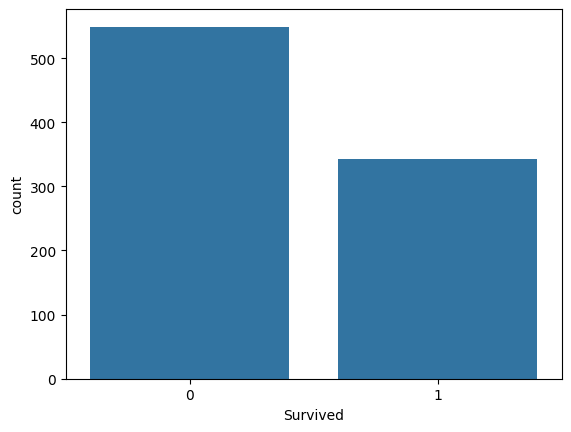

In [54]:
sns.countplot(x='Survived',data=df_copy)
plt.show()

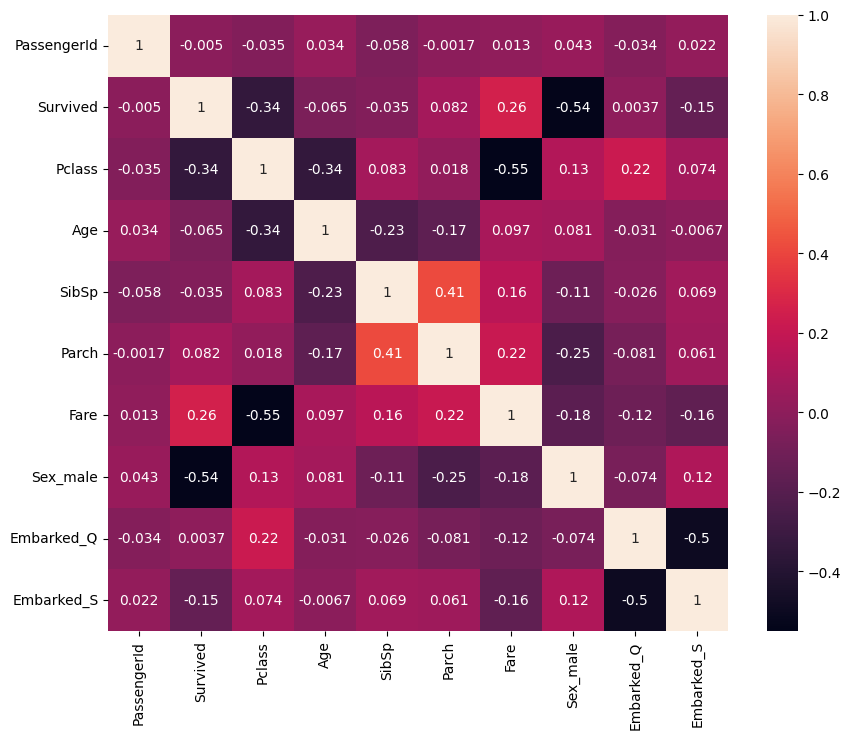

In [55]:
plt.figure(figsize=(10,8))
sns.heatmap(df_copy.corr(),annot=True)
plt.show()

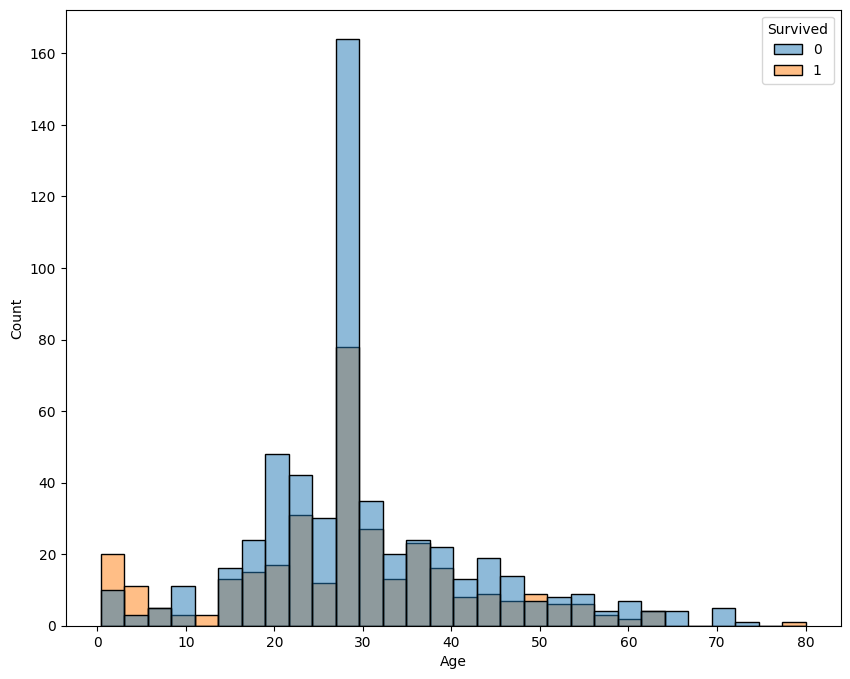

In [56]:
plt.figure(figsize=(10,8))
sns.histplot(x='Age',data=df_copy,hue='Survived')
plt.show()

In [57]:
X=df_copy.drop('Survived',axis=1)
y=df_copy['Survived']

In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [59]:
model=RandomForestClassifier(n_estimators=100,
                            max_depth=5,
                            random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [60]:
model.predict(X_test)

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

In [61]:
accuracy_score(y_test,predict)

0.8156424581005587

In [62]:
confusion_matrix(y_test,predict)

array([[94, 11],
       [22, 52]])

In [63]:
#feature importance
feature_importance=model.feature_importances_
feature_names=X.columns
feature_importance_df=pd.DataFrame({'Feature':feature_names,'Importance':feature_importance})
feature_importance_df=feature_importance_df.sort_values(by='Importance',ascending=False)

In [64]:
new_passenger=pd.DataFrame({
    'PassengerId':[892],
    'Pclass':[3],
    'Age':[25],
    'SibSp':[1],
    'Parch':[0],
    'Fare':[7.25],
    'Sex_male':[1],
    'Embarked_Q':[0],
    'Embarked_S':[0]
})

In [65]:
model.predict(new_passenger)

array([0])

In [66]:
classification_report(y_test,predict)

'              precision    recall  f1-score   support\n\n           0       0.81      0.90      0.85       105\n           1       0.83      0.70      0.76        74\n\n    accuracy                           0.82       179\n   macro avg       0.82      0.80      0.80       179\nweighted avg       0.82      0.82      0.81       179\n'